# Time Series Modeling with Satellite Data #

This notebook will explore the modeling and predicting soil moisture data obtained through soil stations and satellite data using ARIMA and neural networks.

https://www.tensorflow.org/tutorials/structured_data/time_series

In [17]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

import warnings
warnings.filterwarnings("ignore")

## Download data ##

In [36]:
folder_addr = "./merged_data/"
sm_df_list = {}
for i in range(6):
    df = pd.read_csv(folder_addr + 'Station' + str(i + 1) + '_Merged.csv')
    sm_df_list['Station' + str(i + 1)] = {
        'df': df,
        'dates': pd.to_datetime(df.pop('Date'))
    }

In [37]:
sm_df_list['Station1']['df'].head()

,Sat_SM,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
0,0.224324,0.013512,0.171310,0.183661,0.158494,0.171167,18.310714,18.348571,18.318512,18.375119,0.013607,15.396964,74.542381,2.214155,173.944286,172.204821,30.3989,-98.6105
1,0.191104,0.003036,0.164131,0.181077,0.157208,0.170405,19.146905,19.014524,18.803512,18.474048,0.003024,17.210798,70.176905,2.314351,192.251845,204.373869,30.3989,-98.6105
2,0.210310,0.000000,0.155060,0.177470,0.155690,0.169685,20.045655,19.864762,19.577143,18.838036,0.000000,18.358595,68.807440,2.513542,202.383333,215.361131,30.3989,-98.6105
3,0.168200,0.000000,0.146554,0.173161,0.153798,0.168923,20.951429,20.718333,20.360179,19.300536,0.000000,19.392440,70.173571,2.653387,199.038095,213.818155,30.3989,-98.6105
4,0.167357,0.000000,0.139143,0.168560,0.151476,0.168071,21.845476,21.561726,21.136845,19.802083,0.000000,20.166548,70.561905,2.729702,198.314286,221.869821,30.3989,-98.6105


In [38]:
sm_df_list['Station1']['dates'].head()

0   2017-03-18
1   2017-03-19
2   2017-03-20
3   2017-03-21
4   2017-03-22
Name: Date, dtype: datetime64[ns]

## Feature Engineering ##

In [39]:
day = 24 * 60 * 60
year = 365.2425 * day
for station in sm_df_list.keys():
    df = sm_df_list[station]['df']
    dates = sm_df_list[station]['dates']
    wv = df.pop('Windspeed')
    timestamp_s = dates.map(pd.Timestamp.timestamp)
    lat = df.pop('Latitude')
    lon = df.pop('Longitude')
    wd_rad = df.pop('Winddirection') * np.pi / 180
    df['Wx'] = wv * np.cos(wd_rad)
    df['Wy'] = wv * np.sin(wd_rad)
    df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
    df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
    df["x_cord"] = np.cos(lat) * np.cos(lon)
    df["y_cord"] = np.sin(lat) * np.cos(lon)
    df["z_cord"] = np.sin(lon)
    sm_df_list[station] = df

Text(0.5, 1.0, 'Time of year signal')

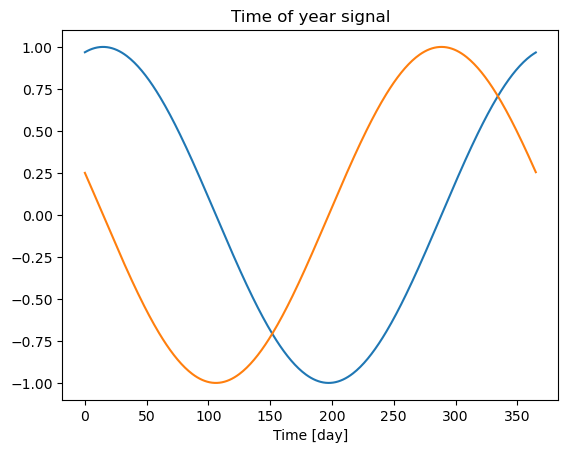

In [40]:
plt.plot(np.array(df['Year sin'])[:366])
plt.plot(np.array(df['Year cos'])[:366])
plt.xlabel('Time [day]')
plt.title('Time of year signal')

## Split and normalize the data ##

In [41]:
def split_data(df, target_col='SWC_5', train_split=0.7, val_split=0.2):
    n = len(df)
    targets = df[target_col]
    train_set = df[0:int(n*train_split)]
    val_set = df[int(n*train_split):int(n*(train_split + val_split))]
    test_set = df[int(n*(train_split + val_split)):]
    return train_set, val_set, test_set, targets

In [42]:
split_sm_df = {}
for station, df in sm_df_list.items():
    # Split the data
    train_set, val_set, test_set, targets = split_data(df)
    
    # Normalize the data
    train_mean = train_set.mean()
    train_std = train_set.std()

    train_set = (train_set - train_mean) / train_std
    val_set = (val_set - train_mean) / train_std
    test_set = (test_set - train_mean) / train_std
    
    # Add split and normalized data to map
    split_sm_df[station] = {
        'train': train_set,
        'val': val_set,
        'test': test_set,
        'target': targets
    }

## Data windowing ##